# **Sesión 2 - VAR bayesianos**
## _A) Del prior a la posterior, paso a paso_

Seguimos con el VAR(2) bivariado de la sesión 1: precios de exportación ($x_t$) e ingresos fiscales
($r_t$), 2002Q2 a 2017Q4. La primera celda rehace en un paso lo que allí construimos a mano (las
matrices $Y$ y $X$ y el estimador de MCO), y desde ahí:

1. Construir $b_0$ y $H$ del prior de Minnesota.
2. Programar el Gibbs Sampler.
3. Contrastar con `MacroPy`.
4. Medir cuánto encoge el prior.

La notación sigue las diapositivas: $B$ ($k \times n$) apila los coeficientes con la constante en la
**primera** fila y $b = \operatorname{vec}(B)$. El código está en inglés; el texto, en castellano.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart, norm

from MacroPy import BayesianVAR
from MacroPy.priors import MinnesotaPrior
from MacroPy.plots_kalman import set_bse_style
import sys; sys.path.append("..")          # course_data.py vive en la raíz del repositorio
from course_data import load, macrofiscal, quarter, vintage

set_bse_style()

# Datos y forma compacta: lo que construimos en la sesión 1
# ================================================================
levels = load()                               # copia congelada de la base del curso
data = macrofiscal(levels).loc[:"2017-12-01", ["x", "r"]]
n, p = 2, 2
y = data.to_numpy()
T = len(y) - p
Y = y[p:]
X = np.column_stack([np.ones(T), y[p - 1:-1], y[p - 2:-2]])
k = X.shape[1]
rows = ["constante", "x(-1)", "r(-1)", "x(-2)", "r(-2)"]
B_ols = np.linalg.solve(X.T @ X, X.T @ Y)
U = Y - X @ B_ols

print(f"Base del curso, descargada el {vintage()}")
print(f"Muestra: {quarter(data.index[0])} a {quarter(data.index[-1])} ({len(data)} trimestres); "
      f"Y {Y.shape}, X {X.shape}")

Base del curso, descargada el 2026-10-03
Muestra: 2002Q2 a 2017Q4 (63 trimestres); Y (61, 2), X (61, 5)


## 1. El prior de Minnesota: $b_0$ y $H$

Con $b = \operatorname{vec}(B)$, primero la ecuación de $x$ y luego la de $r$, cada una en el orden
constante, $x_{t-1}$, $r_{t-1}$, $x_{t-2}$, $r_{t-2}$:

- media a priori: $\delta_i$ en el primer rezago propio y cero en el resto;
- varianza del rezago propio $\ell$: $(\lambda_1/\ell^{\lambda_3})^2$;
- varianza del rezago $\ell$ de la variable $j$ en la ecuación $i$: $\big(\lambda_1\lambda_2\,\sigma_i/(\ell^{\lambda_3}\sigma_j)\big)^2$;
- varianza de la constante: $(\sigma_i \lambda_4)^2$, difusa.

$\sigma_i$ es la desviación estándar del residuo de una regresión AR univariada de la variable $i$;
`MacroPy` usa un AR(1) con constante y aquí lo replicamos para poder comparar. Valores clásicos:
$\lambda_1 = 0.2$, $\lambda_2 = 0.5$, $\lambda_3 = 1$, $\lambda_4 = 10^5$, y $\delta_i = 0.5$ porque
los crecimientos interanuales son persistentes pero revierten.

In [3]:
delta, l1, l2, l3, l4 = 0.5, 0.2, 0.5, 1.0, 1e5

def ar1_residual_sd(y_col, own_lag):
    """AR(1) with constant on the own-lag column of X, as MacroPy."""
    Z = np.column_stack([own_lag, np.ones(len(y_col))])
    coef = np.linalg.lstsq(Z, y_col, rcond=None)[0]
    resid = y_col - Z @ coef
    return np.sqrt(resid @ resid / (len(y_col) - 2))

sigma = np.array([ar1_residual_sd(Y[:, 0], X[:, 1]),
                  ar1_residual_sd(Y[:, 1], X[:, 2])])

b0 = np.zeros(n * k)
H_diag = np.zeros(n * k)
for i in range(n):                           # equation i
    first = i * k
    b0[first + 1 + i] = delta                # first own lag
    H_diag[first] = (sigma[i] * l4) ** 2     # diffuse constant
    for lag in (1, 2):
        for j in range(n):                   # variable j
            pos = first + 1 + (lag - 1) * n + j
            if i == j:
                H_diag[pos] = (l1 / lag ** l3) ** 2
            else:
                H_diag[pos] = (l1 * l2 * sigma[i]
                               / (lag ** l3 * sigma[j])) ** 2
H = np.diag(H_diag)

labels = [f"{eq}: {row}" for eq in ("x", "r") for row in rows]
print(f"sigma_1 (x) = {sigma[0]:.3f}   sigma_2 (r) = {sigma[1]:.3f}")

# MacroPy puts the constant last in each equation: reorder to compare.
minnesota = {"mn_mean": delta, "lambda1": l1, "lambda2": l2,
             "lambda3": l3, "lambda4": l4}
prior_macropy = MinnesotaPrior(Y, X[:, [1, 2, 3, 4, 0]], lags=2,
                               ncoeff_eq=k, prior_params=minnesota)
order = np.r_[[4, 0, 1, 2, 3], [9, 5, 6, 7, 8]]     # constant first
sd_prior = np.sqrt(H_diag)
sd_macropy = np.sqrt(np.diag(prior_macropy["H"])[order])
print("max |b0 propio - b0 MacroPy| =",
      np.abs(b0 - prior_macropy["b0"][order]).max())
print("max |sqrt(H) propio - sqrt(H) MacroPy| relativo =",
      f"{np.max(np.abs(sd_prior - sd_macropy) / sd_prior):.1e}")
pd.DataFrame({"b0": b0, "desv. est. a priori": sd_prior},
             index=labels).round(3)

sigma_1 (x) = 9.473   sigma_2 (r) = 6.879
max |b0 propio - b0 MacroPy| = 0.0
max |sqrt(H) propio - sqrt(H) MacroPy| relativo = 0.0e+00


,b0,desv. est. a priori
x: constante,0.0,947280.272
x: x(-1),0.5,0.200
x: r(-1),0.0,0.138
x: x(-2),0.0,0.100
x: r(-2),0.0,0.069
r: constante,0.0,687863.228
r: x(-1),0.0,0.073
r: r(-1),0.5,0.200
r: x(-2),0.0,0.036
r: r(-2),0.0,0.100


## 2. El muestreador de Gibbs, a mano

El VAR tiene dos bloques de parámetros y cada uno tiene una condicional conocida:

1. Definir priors para $b$ y $\Sigma$. Valor inicial para $\Sigma$ (partimos de $\hat\Sigma_{\text{MCO}}$).
2. Muestrear $b^{(m)}$ desde $b \mid \Sigma, Y \sim N(\bar b, \bar V)$, donde:
   $$ \bar V = [H^{-1} + \Sigma^{-1}\otimes X'X]^{-1} \qquad y \qquad \bar b = \bar V\,[H^{-1}b_0 + (\Sigma^{-1}\otimes X')\,y] $$
3. Muestrear $\Sigma^{(m)}$ desde $\Sigma \mid b, Y \sim \mathcal{IW}\big(\bar{S}, \bar{\nu}\big)$, donde:
   $$ \bar{S} = S_0 + (Y - XB)'(Y - XB) \qquad y \qquad \bar{\nu} = \nu_0 + T $$
4. Repetir el 2do y 3er paso $M$ veces para obtener $b^{(1)}, \cdots, b^{(M)}$ y $\Sigma^{(1)},\cdots, \Sigma^{(M)}$. Descartamos las extracciones explosivas, después del _burn-in_.

Para $\Sigma$ usamos el mismo prior que `MacroPy`: $\nu_0 = n + 2$ y
$S_0 = (\nu_0 - n - 1)\operatorname{diag}(\sigma_1^2, \sigma_2^2)$.

In [4]:
rng = np.random.default_rng(42)
M, burn = 6000, 1000
nu0 = n + 2
S0 = (nu0 - n - 1) * np.diag(sigma ** 2)
H_inv = np.diag(1 / H_diag)
XtX = X.T @ X
vec_Y = Y.flatten(order="F")
b_ols = B_ols.flatten(order="F")

def is_stable(B):
    """Largest modulus of the companion eigenvalues below one."""
    F = np.zeros((n * p, n * p))
    F[:n, :] = B[1:, :].T
    F[n:, :n] = np.eye(n)
    return np.abs(np.linalg.eigvals(F)).max() < 1

Sigma = U.T @ U / (T - k)                    # start at Sigma_MCO
draws_b = np.zeros((M, n * k))
draws_S = np.zeros((M, n, n))
for m in range(M):
    Sigma_inv = np.linalg.inv(Sigma)
    V = np.linalg.inv(H_inv + np.kron(Sigma_inv, XtX))
    V = (V + V.T) / 2
    b_bar = V @ (H_inv @ b0 + np.kron(Sigma_inv, X.T) @ vec_Y)
    L = np.linalg.cholesky(V)
    while True:                              # step 1: coefficients
        b = b_bar + L @ rng.standard_normal(n * k)
        B = b.reshape((k, n), order="F")
        if is_stable(B):
            break
    E = Y - X @ B                            # step 2: covariance
    Sigma = invwishart.rvs(df=nu0 + T, scale=S0 + E.T @ E, random_state=rng)
    draws_b[m], draws_S[m] = b, Sigma

kept = draws_b[burn:]
print(f"{M} iteraciones, {M - burn} extracciones conservadas")

6000 iteraciones, 5000 extracciones conservadas


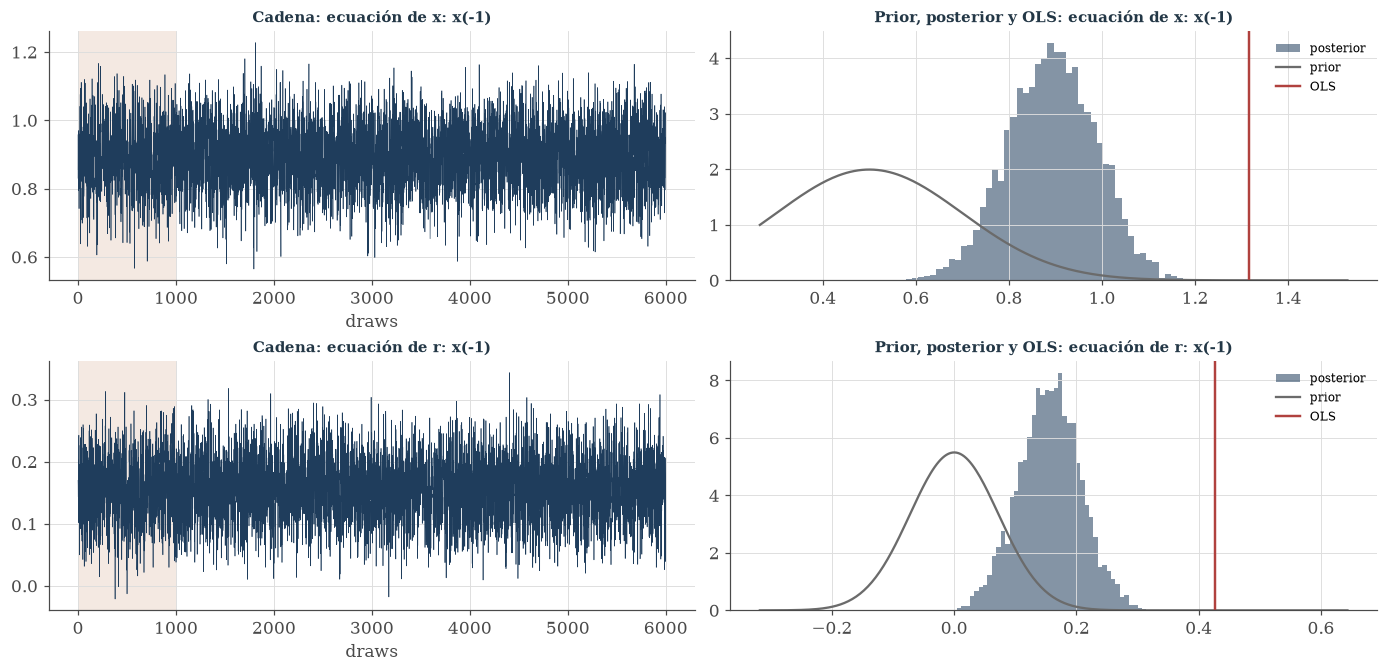

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6), constrained_layout=True)
cases = ((1, "ecuación de x: x(-1)"), (k + 1, "ecuación de r: x(-1)"))
for row, (pos, title) in enumerate(cases):
    ax = axes[row, 0]
    ax.axvspan(0, burn, color="#F0E0D6", alpha=0.7, lw=0)
    ax.plot(draws_b[:, pos], color="#1F3D5C", lw=0.4)
    ax.set_title(f"Cadena: {title}", fontsize=10)
    ax.set_xlabel("draws")
    ax = axes[row, 1]
    ax.hist(kept[:, pos], bins=50, density=True, color="#1F3D5C",
            alpha=0.55, label="posterior")
    grid = np.linspace(kept[:, pos].min() - 0.3,
                       kept[:, pos].max() + 0.3, 300)
    ax.plot(grid, norm.pdf(grid, b0[pos], np.sqrt(H_diag[pos])),
            color="#6B6B6B", lw=1.5, label="prior")
    ax.axvline(b_ols[pos], color="#B0413E", lw=1.6, label="OLS")
    ax.set_title(f"Prior, posterior y OLS: {title}", fontsize=10)
    ax.legend(fontsize=8)
plt.show()

Las cadenas se estabilizan casi de inmediato: con priors conjugados y solo diez coeficientes, el
*burn-in* es holgado. En los histogramas se ve el promedio ponderado por precisión de las
diapositivas: la posterior queda **entre el prior y MCO**, y más cerca de MCO donde el dato es
informativo.

## 3. Contraste con `MacroPy`

`BayesianVAR` con `prior_type=2` es el mismo modelo: prior de Minnesota para los coeficientes e
inversa-Wishart para la covarianza. Si nuestro muestreador está bien, las medias posteriores tienen
que coincidir dentro del error de Monte Carlo.

In [8]:
bvar = BayesianVAR(data, lags=2, prior_type=2, prior_params=minnesota,
                   post_draws=M, burnin=burn / M, seed=42)
bvar.sample_posterior()
mean_macropy = np.asarray(bvar.beta_draws).mean(0)[order]
table = pd.DataFrame({"MCO": b_ols, "Gibbs a mano": kept.mean(0),
                      "MacroPy": mean_macropy}, index=labels)
table["dif. mano - MacroPy"] = table["Gibbs a mano"] - table["MacroPy"]
table.round(3)

Sampling Posterior: 100%|██████████| 6000/6000 [00:01<00:00, 5963.80it/s]


,MCO,Gibbs a mano,MacroPy,dif. mano - MacroPy
x: constante,2.025,2.395,2.396,-0.001
x: x(-1),1.316,0.893,0.893,-0.000
x: r(-1),-0.067,-0.006,-0.006,0.000
x: x(-2),-0.518,-0.115,-0.116,0.001
x: r(-2),0.049,-0.030,-0.028,-0.002
r: constante,1.199,1.431,1.441,-0.011
r: x(-1),0.427,0.156,0.157,-0.001
r: r(-1),0.464,0.574,0.574,0.000
r: x(-2),-0.179,0.012,0.011,0.001
r: r(-2),0.004,-0.027,-0.029,0.001


## 4. ¿Cuánto encoge el prior?

La intensidad del encogimiento depende de $\lambda_1$. Comparamos MCO con dos priors: el clásico
($\lambda_1 = 0.2$, $\lambda_2 = 0.5$) y uno laxo ($\lambda_1 = 2$, $\lambda_2 = 1$), que es el que
usa el modelo macrofiscal del notebook 2.

In [6]:
loose = BayesianVAR(data, lags=2, prior_type=2,
                    prior_params={"mn_mean": delta, "lambda1": 2,
                                  "lambda2": 1},
                    post_draws=M, burnin=burn / M, seed=42)
loose.sample_posterior()
mean_loose = np.asarray(loose.beta_draws).mean(0)[order]
comparison = pd.DataFrame(
    {"media a priori": b0, "MCO": b_ols,
     "prior clásico (λ1 = 0.2)": mean_macropy,
     "prior laxo (λ1 = 2)": mean_loose},
    index=labels).drop(index=["x: constante", "r: constante"])
prior_mean = comparison["media a priori"]
comparison["|MCO - b0|"] = (comparison["MCO"] - prior_mean).abs()
comparison["|clásico - b0|"] = (
    comparison["prior clásico (λ1 = 0.2)"] - prior_mean).abs()
closer = (comparison["|clásico - b0|"] < comparison["|MCO - b0|"]).sum()
print("Coeficientes que la posterior acerca a la media a priori:",
      f"{closer} de {len(comparison)}")
comparison.round(3)

Sampling Posterior: 100%|██████████| 6000/6000 [00:01<00:00, 5939.09it/s]

Coeficientes que la posterior acerca a la media a priori: 6 de 8


,media a priori,MCO,prior clásico (λ1 = 0.2),prior laxo (λ1 = 2),|MCO - b0|,|clásico - b0|
x: x(-1),0.5,1.316,0.893,1.301,0.816,0.393
x: r(-1),0.0,-0.067,-0.006,-0.067,0.067,0.006
x: x(-2),0.0,-0.518,-0.116,-0.497,0.518,0.116
x: r(-2),0.0,0.049,-0.028,0.038,0.049,0.028
r: x(-1),0.0,0.427,0.157,0.421,0.427,0.157
r: r(-1),0.5,0.464,0.574,0.462,0.036,0.074
r: x(-2),0.0,-0.179,0.011,-0.171,0.179,0.011
r: r(-2),0.0,0.004,-0.029,0.001,0.004,0.029


El _shrinkage_ (encogimiento) se mide como **distancia a la media a priori**, no como porcentaje de MCO: el
rezago propio tiene media 0.5, y un porcentaje sobre un coeficiente casi nulo no significa nada.

Con el prior clásico, el _shrinkage_ muerde sobre todo en los **rezagos cruzados** y en los de
**orden dos**: el coeficiente de $x_{t-1}$ en la ecuación de $r$ pasa de 0.43 a 0.16, y el de
$x_{t-2}$ en la ecuación de $x$, de $-0.52$ a $-0.12$. Los coeficientes que no se acercan al prior
están en la ecuación de $r$: al encoger los demás, la persistencia se reacomoda en el rezago propio.

Con el prior laxo la posterior es casi MCO: con dos variables y 61 observaciones no hace falta encoger
mucho. El _shrinkage_ se vuelve imprescindible cuando crecen las variables o los rezagos.

## Ejercicios

1. Cambie $\delta_i$ a 0 y a 1. ¿Qué coeficientes se mueven y por qué?
2. Reduzca $\lambda_1$ a 0.05. ¿Cuánto se acerca la posterior al prior? ¿Qué pasa con el ajuste?
3. Repita el muestreador sin descartar las extracciones explosivas. ¿Cambia algo en esta muestra?
   ¿Cuándo esperaría que sí?
4. Agregue un tercer rezago y cuente cuántos coeficientes nuevos aparecen en $b$ y en $H$.